In [1]:
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np

# Enable interactive backend
%matplotlib widget

In [2]:
# Load necessary files
pltfile = PltFileUtils('./cylinder.plt')
rstfile = UnkFileUtils('./cylinder.rst', extend=False)

# Extract the side surface
side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=3)

# note : flag = 3 is the flag on the out of plane surface, the xy plane
# flag = 4 is the bottom plane and flag = 3 is the top plane

# Compute flow primitives 
rstfile._primitive()

# Extract pressure values from the rst file, only at the side_nodes (top suface xy plane)
side_p = rstfile.p[side_nodes]

# Extract x-velocity values from the rst file, only at the side_nodes (top suface xy plane)
side_ux = rstfile.ux[side_nodes]

# Extract density values from the rst file, only at the side_nodes (top suface xy plane)
side_rho = rstfile.rho[side_nodes]

# 3060 nodes in .rst and .plt in total

In [3]:
type(side_p)
side_p.shape
rstfile.p.shape

(3060,)

In [4]:
# use some utilities from GrpFileUtils
tmp_grp = GrpFileUtils('tmp', 0, 
                       read=False,
                       coord=side_coords, 
                       nodes=side_nodes)
tmp_grp.root_nodemap = side_nodemap 

In [5]:
# setting x and y bounds for the data
x_upper = 20
x_lower = -5
y_upper = 5
y_lower = -5

# Filter points based on x and y coordinate bounds 
node_filter = (side_coords[:, 0] > x_lower) & (side_coords[:, 0] < x_upper) & (side_coords[:, 1] > y_lower) & (side_coords[:, 1] < y_upper )
tmp_grp.node_filter = node_filter

# Extract triangle nodemap
tri_nodemap = tmp_grp.get_tri_nodemap() 

In [6]:
print(node_filter)

[ True  True  True ...  True  True  True]


In [7]:
# saving the x and y coordinates to grp_x and grp_y

grp_x = tmp_grp.coords[:, 0]
grp_y = tmp_grp.coords[:, 1]
# Construct a matplotlib Triangulation (defines our mesh for plotting)
tri = Triangulation(grp_x, grp_y, triangles=tri_nodemap)

In [8]:
print(side_rho.shape)

(1315,)


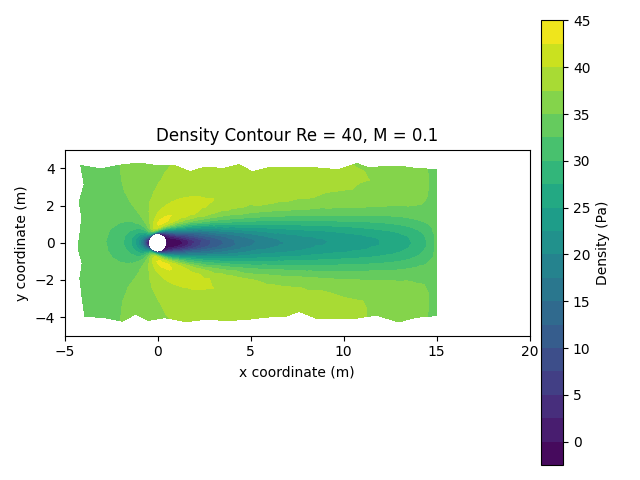

In [ ]:
# density plot
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, side_rho[node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='Density (Pa)')
ax.set_title("Density Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.set_aspect('equal', 'box') # forcing the scale of x and y axis to equal
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()

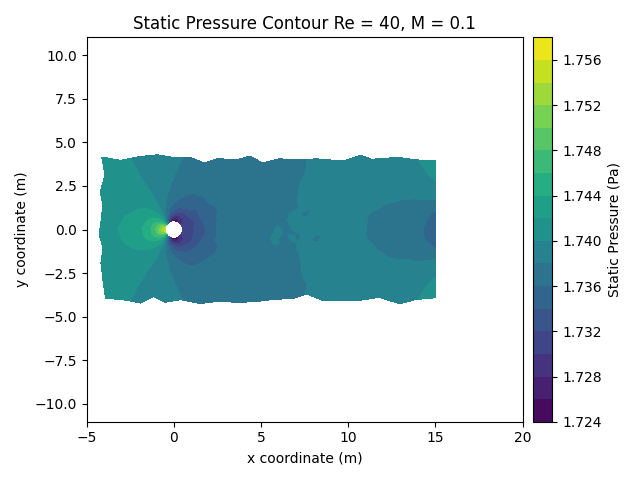

In [10]:

# plotting static pressure Pa
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, side_p[node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='Static Pressure (Pa)')
ax.set_title("Static Pressure Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.axis('equal') # forcing the scale of x and y axis to equal
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()


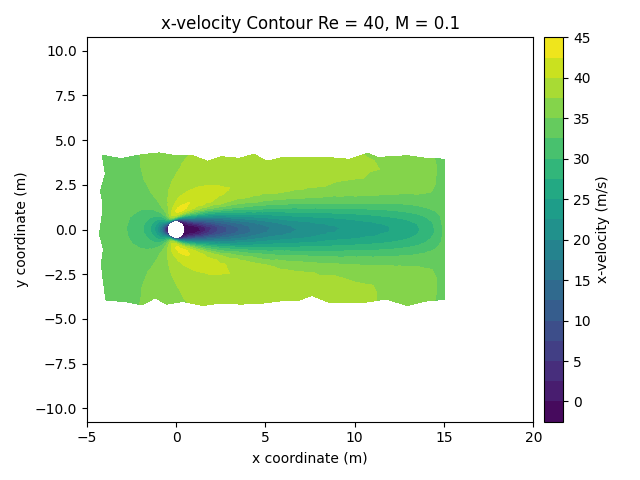

In [11]:
# plotting x-velocity
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, side_ux[node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='x-velocity (m/s)')
#ax.clabel(contour, inline=True, fontsize=8, fmt="%.2f", colors = "black")
ax.set_title("x-velocity Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.axis('equal')
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()

In [12]:
# creating a sample line from (0.5, 0) to (5,0)
x_line_start, x_line_end = 0, 3
y_line = 0
tolerance = 1e-1   # small tolerance for y
# Filter points based on x and y coordinate 
# Sampling points on the line (0.5, 0) to (5,0)
# The tolerance is important because your mesh may not have exact y = 0 values.
line_filter = (
    (side_coords[:, 0] >= x_line_start) &
    (side_coords[:, 0] <= x_line_end) &
    (abs(side_coords[:, 1] - y_line) < tolerance)
)

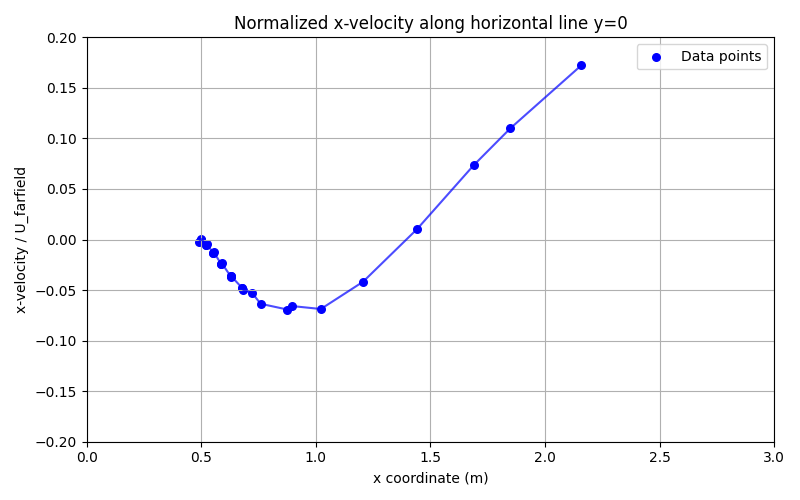

In [13]:
# define farfield velocity (m/s)
U_farfield = 34.0297 
# Apply the filter to coordinates and x-velocity
filtered_coords = side_coords[line_filter]
filtered_ux = side_ux[line_filter]

# Extract x and y
x_line = filtered_coords[:, 0]
y_line = filtered_coords[:, 1]  # optional, not needed for x-velocity vs x

# Sort x_line and filtered_ux
sort_idx = np.argsort(x_line)
x_sorted = x_line[sort_idx]
ux_sorted = filtered_ux[sort_idx] / U_farfield  # normalize after sorting

# Scatter plot (with line to show trend)
plt.figure(figsize=(8,5))
plt.scatter(x_sorted, ux_sorted, color='blue', s=30, marker='o', label='Data points')
plt.plot(x_sorted, ux_sorted, color='blue', linestyle='-', alpha=0.7)

plt.xlabel("x coordinate (m)")
plt.ylabel("x-velocity / U_farfield")
plt.title("Normalized x-velocity along horizontal line y=0")
plt.xlim(0,3)
plt.ylim(-0.2, 0.2)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# imported experimental data
import pandas as pd
import matplotlib.pyplot as plt

u_profile_re40_set1 = pd.read_csv("U_profile_Re40_MADELEINE.csv") 
u_profile_re40_set2 = pd.read_csv("U_profile_Re40_Nieuwstadt _Keller.csv") 
plt.plot(u_profile_re40_set1["x"], u_profile_re40_set1[" y"], label = "Experiment Mandeleine")
plt.plot(u_profile_re40_set2["x"], u_profile_re40_set2[" y"], label = "Experiment Keller")
plt.legend()